# 反向扩散采样的数值分析
## —— 后向误差分析、稳定性、误差预算与少步采样

**作者**：牛昱琛　**学号**：253108120111　（单人独立完成）
**课程**：《人工智能数理基础（高级）》开放课题 · 方向 **SC4AI**
**日期**：2026 年 5 月

---

> **摘要.** 本文把扩散模型（score-based / SDE 生成模型）的**反向采样**重新表述为"**数值求解一个反向时间随机微分方程（SDE）/概率流常微分方程（ODE）**"的问题，并用**数值分析**的工具系统地理解与改进它。在数据为各向同性高斯的可解析设定下，反向过程是**线性 SDE**，其矩满足**闭式确定性递推**，从而每一个理论命题都有**解析真值**作硬基准、结论可证伪。我们：(i) 用**后向误差分析 / 修正方程**解析地推出 Euler–Maruyama 采样在生成分布方差上引入的领头阶 $O(h)$ 偏差及其**闭式系数**，并以 Richardson 外推独立交叉验证（相对误差约 6%）；(ii) 修正并澄清了 EM 在**加性噪声**下的**强收敛阶为 1**（而非教科书中乘性噪声的 1/2）；(iii) 用**刚性 / 绝对稳定域**第一性地解释采样步长上界 $h\le 2/a(t)$；(iv) 推导半隐式 / 指数积分器与概率流 ODE 的**闭式解** $x\propto\sqrt{v}$，并诚实评测少步采样；(v) 给出总采样误差的**三分解**（分数 / 离散 / 先验）与 **Fokker–Planck 残差**诊断；(vi) 迁移到训练所得网络 score，定量定位**离散误差与网络逼近误差的交叉点**。所有实验在 2-D 以下、Apple Silicon（torch MPS）上分钟级完成，配套库 `diffusion_na.py` 通过 23 项 pytest 数值自检。

## Part 0　引言：把"采样"当作"数值积分"

### 0.1 背景与计算难点
扩散模型已成为图像、音频、分子等生成任务的主流方法。其核心是一个**前向加噪过程**（把数据逐步变成噪声）和一个**反向去噪过程**（把噪声逐步变回数据）。Song 等人（2021）指出二者都可写成连续时间 SDE：前向

$$\mathrm{d}X_t = -\tfrac12\beta(t)X_t\,\mathrm{d}t + \sqrt{\beta(t)}\,\mathrm{d}W_t,\qquad t\in(0,1],$$

而反向（生成）由 Anderson（1982）时间反演给出。**实践中真正昂贵且充满"玄学"的，是反向采样这一步**：用多少步、用什么离散格式、噪声调度怎么选、为什么少步采样会糊——这些恰恰是**数值分析**（数值 ODE/SDE 的相容性、收敛阶、稳定性、刚性、后向误差分析）最擅长回答的问题。

### 0.2 本文视角（SC4AI）
> **把反向采样看成"数值求解反向时间 SDE / 概率流 ODE"，用科学计算的理论来解释与改进这一 AI 方法。**

这正是课程"SC4AI（科学计算支撑人工智能）"的主旨。我们刻意选择**数据为高斯**的可解析设定：此时反向过程是**线性 SDE**，其均值/方差有**闭式**，于是"EM 实际在采哪条被修正的分布""偏差有多大""何时失稳"都能与**解析真值**逐一对照——可证伪，而非经验调参。

### 0.3 与课程内容的呼应
- **Lect6（扩散模型与反向 SDE）**：本文以其 VP-SDE / 去噪分数匹配（DSM）/ Swiss-Roll 为实验基线并深化之。
- **Lect5（SGD 与修正方程）**：本文的"采样修正方程"与该讲的"SGD 修正方程"是**同一个后向误差分析工具**，体现整门课"**微分方程是理解 AI 的统一视角**"。

### 0.4 主要贡献
1. **后向误差分析**：解析推出反向 EM 生成分布方差的领头阶 $O(h)$ 偏差闭式系数 $c$，并以 Richardson 外推交叉验证（相对误差约 6%，见实验②）。
2. **澄清收敛阶**：指出本问题为**加性噪声**，EM 的**强阶=弱阶=1**；以共享布朗路径数值验证，并与乘性噪声（强阶 1/2）对比（实验③）。
3. **稳定性/刚性**：以显式 Euler 绝对稳定域给出步长上界 $h\le 2/a(t)$，并定位最刚处在 $t\approx1$（实验④）。
4. **改进采样器**：半隐式/指数积分器降低误差常数；概率流 ODE 的**闭式精确解** $x(t)=\sqrt{v(t)/v(1)}\,x(1)$ 作机器精度参照；NFE–质量 Pareto 与**诚实负结果**（实验⑤⑥）。
5. **误差预算**：总采样误差的分数/离散/先验**三分解**（实验⑧）；**Fokker–Planck 残差**作 score 质量的后验诊断（实验⑨）。
6. **网络迁移**：训练 DSM 网络 score，定量定位**离散误差↔网络逼近误差交叉点**（实验⑩）。

### 0.5 阅读导航
Part I 理论基础 → Part II 误差与收敛（实验①②③）→ Part III 稳定性与刚性（④）→ Part IV 改进采样器（⑤⑥⑦）→ Part V 误差预算与诊断（⑧⑨⑩）→ Part VI 总结。所有数值函数集中在 `diffusion_na.py`。

In [1]:
# === 工具区：内联核心库 diffusion_na（使本 notebook 单文件自包含；与 diffusion_na.py 一致，经 23 项 pytest 数值自检）===
# 说明：下方字符串即 diffusion_na.py 全部源码；执行后注册为模块 dna，后续 `import diffusion_na as dna` 直接可用。
import types as _types, sys as _sys
_DIFFUSION_NA_SRC = '"""diffusion_na —— 反向扩散采样的数值分析 · 核心库（经 pytest 数值自检）。\n\n统一时间约定（全程严格一致，已数值核验）\n------------------------------------------------\n- VP 前向 SDE:  dX = -1/2 beta(t) X dt + sqrt(beta(t)) dW,  t in (0,1].\n- beta(t) = 0.1 + 19.9 t,  B(t) = ∫_0^t beta = 0.1 t + 9.95 t^2.\n- 数据 X0 ~ N(0, s0^2 I)，默认 s0 = DATA_STD = 0.5（s0 = 1 退化，禁用）。\n- 边缘 v(t) = 1 + (s0^2 - 1) e^{-B(t)}，精确 score  s*(x,t) = -x / v(t)（线性）。\n- 反向漂移系数 a(t) = beta(t) (1/v(t) - 1/2) > 0。\n- 反向采样网格 t_n: 1 -> eps，正步长 h = t_n - t_{n+1} > 0。\n    EM 一步:        x_{n+1} = (1 - a(t_n) h) x_n + sqrt(beta(t_n) h) z\n    方差递推:        V_{n+1} = (1 - a(t_n) h)^2 V_n + beta(t_n) h\n- 反向时间 tau = 1 - t:  dV/dtau = -2 a(1-tau) V + beta(1-tau)  （★ 含因子 2）\n- 概率流 ODE:  前向 f_pf(t,x) = 1/2 beta(t) (1/v(t) - 1) x；\n    高斯闭式精确解  x(t) = sqrt(v(t)/v(1)) x(1)。\n"""\nfrom __future__ import annotations\n\nimport numpy as np\nfrom scipy.integrate import solve_ivp\nfrom scipy.special import logsumexp\n\nBETA_MIN = 0.1\nBETA_MAX = 20.0\nDATA_STD = 0.5\nEPS = 1e-3\nSEED = 2026\n\n_trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz  # numpy>=2.0 改名\n\n\n# ----------------------------------------------------------------------\n# 1. 调度、边缘分布与精确 score\n# ----------------------------------------------------------------------\ndef beta(t):\n    return BETA_MIN + (BETA_MAX - BETA_MIN) * np.asarray(t, dtype=float)\n\n\ndef int_beta(t):\n    """B(t) = ∫_0^t beta(s) ds."""\n    t = np.asarray(t, dtype=float)\n    return BETA_MIN * t + 0.5 * (BETA_MAX - BETA_MIN) * t ** 2\n\n\ndef alpha(t):\n    """转移核均值尺度 e^{-B/2}."""\n    return np.exp(-0.5 * int_beta(t))\n\n\ndef sigma2(t):\n    """转移核方差 1 - e^{-B}（数值稳定）."""\n    return -np.expm1(-int_beta(t))\n\n\ndef marginal_var(t, s0=DATA_STD):\n    """各向同性高斯数据的边缘方差 v(t)."""\n    return 1.0 + (s0 ** 2 - 1.0) * np.exp(-int_beta(t))\n\n\ndef _log_marginal_gaussian(x, t, s0=DATA_STD):\n    x = np.asarray(x, dtype=float)\n    v = marginal_var(t, s0)\n    d = x.size\n    return -0.5 * np.sum(x ** 2) / v - 0.5 * d * np.log(2 * np.pi * v)\n\n\ndef exact_score_gaussian(x, t, s0=DATA_STD):\n    """∇ log p(x,t) = -x / v(t)（线性）."""\n    return -np.asarray(x, dtype=float) / marginal_var(t, s0)\n\n\n# ----------------------------------------------------------------------\n# 2. 高斯混合的闭式边缘与 score（批量 [N,d] -> [N,d]）\n# ----------------------------------------------------------------------\ndef _component_var(t, s0):\n    return alpha(t) ** 2 * s0 ** 2 + sigma2(t)\n\n\ndef gmm_log_marginal(x, t, means, weights, s0=0.4):\n    x = np.atleast_2d(np.asarray(x, float))            # [N,d]\n    means = np.asarray(means, float)                   # [K,d]\n    w = np.asarray(weights, float)                     # [K]\n    vt = _component_var(t, s0)\n    d = x.shape[1]\n    mu = alpha(t) * means                              # [K,d]\n    sq = np.sum((x[:, None, :] - mu[None, :, :]) ** 2, axis=-1)  # [N,K]\n    logc = -0.5 * d * np.log(2 * np.pi * vt)\n    logp_k = logc - 0.5 * sq / vt                      # [N,K]\n    return logsumexp(logp_k, b=w[None, :], axis=1)     # [N]\n\n\ndef exact_score_gmm(x, t, means, weights, s0=0.4):\n    x = np.atleast_2d(np.asarray(x, float))            # [N,d]\n    means = np.asarray(means, float)                   # [K,d]\n    w = np.asarray(weights, float)                     # [K]\n    vt = _component_var(t, s0)\n    mu = alpha(t) * means                              # [K,d]\n    diff = mu[None, :, :] - x[:, None, :]              # [N,K,d]\n    sq = np.sum(diff ** 2, axis=-1)                    # [N,K]\n    logp = np.log(w)[None, :] - 0.5 * sq / vt          # [N,K]\n    logp = logp - logp.max(axis=1, keepdims=True)\n    r = np.exp(logp)\n    r = r / r.sum(axis=1, keepdims=True)               # 后验权重 [N,K]\n    return np.sum(r[:, :, None] * diff / vt, axis=1)   # [N,d]\n\n\n# ----------------------------------------------------------------------\n# 3. 反向动力学与精确方差参照（含因子 2）\n# ----------------------------------------------------------------------\ndef reverse_drift_coeff(t, s0=DATA_STD):\n    """a(t) = beta(t)(1/v(t) - 1/2) > 0."""\n    return beta(t) * (1.0 / marginal_var(t, s0) - 0.5)\n\n\ndef reverse_variance_exact(t_end, s0=DATA_STD, t_start=1.0, V_start=None, dense=False):\n    """高精度求解反向方差 ODE dV/dtau = -2 a V + beta（含因子 2）。\n\n    V_start=None 时取真值起点 marginal_var(t_start)（隔离离散误差）。\n    dense=True 返回 OdeSolution（供取二阶导）。\n    """\n    if V_start is None:\n        V_start = marginal_var(t_start, s0)\n\n    def rhs(tau, V):\n        t = t_start - tau\n        a = reverse_drift_coeff(t, s0)\n        return [-2.0 * a * V[0] + beta(t)]            # ★ 因子 2\n\n    tau_end = t_start - t_end\n    sol = solve_ivp(rhs, [0.0, tau_end], [float(V_start)],\n                    rtol=1e-10, atol=1e-10, dense_output=True)\n    return sol if dense else float(sol.y[0, -1])\n\n\n# ----------------------------------------------------------------------\n# 4. 反向 EM 方差确定性递推 + 随机采样器（互校）\n# ----------------------------------------------------------------------\ndef em_variance_recursion(N, eps=EPS, s0=DATA_STD, t_start=1.0, V_start=1.0):\n    ts = np.linspace(t_start, eps, N + 1)\n    V = float(V_start)\n    for i in range(N):\n        t = ts[i]\n        h = ts[i] - ts[i + 1]\n        a = reverse_drift_coeff(t, s0)\n        V = (1.0 - a * h) ** 2 * V + beta(t) * h\n    return V\n\n\ndef em_sample(N, n_samples=10000, eps=EPS, s0=DATA_STD, dim=1, seed=0, x_start=None):\n    rng = np.random.default_rng(seed)\n    ts = np.linspace(1.0, eps, N + 1)\n    if x_start is None:\n        x = rng.standard_normal((n_samples, dim))      # 先验 N(0,I)\n    else:\n        x = np.array(x_start, dtype=float)\n    for i in range(N):\n        t = ts[i]\n        h = ts[i] - ts[i + 1]\n        a = reverse_drift_coeff(t, s0)\n        x = (1.0 - a * h) * x + np.sqrt(beta(t) * h) * rng.standard_normal(x.shape)\n    return x\n\n\n# ----------------------------------------------------------------------\n# 5. O(h) 偏差律与修正方程系数（后向误差分析）\n# ----------------------------------------------------------------------\ndef bias_coeff_empirical(eps=EPS, s0=DATA_STD, Ns=(800, 1600, 3200, 6400)):\n    """Richardson 外推得 (V_N - target)/h 在 h->0 的极限 c_emp."""\n    target = reverse_variance_exact(eps, s0=s0, V_start=marginal_var(1.0, s0))\n    Vs = np.array([em_variance_recursion(N, eps=eps, s0=s0, V_start=marginal_var(1.0, s0))\n                   for N in Ns])\n    hs = (1.0 - eps) / np.array(Ns, dtype=float)\n    ratios = (Vs - target) / hs\n    A = np.vstack([np.ones_like(hs), hs]).T\n    return float(np.linalg.lstsq(A, ratios, rcond=None)[0][0])\n\n\ndef bias_coeff_theory(eps=EPS, s0=DATA_STD, M=40000):\n    """闭式领头阶偏差系数 c = ∫ Phi(T,s)[a^2 V - 1/2 V\'\'] ds，Phi=exp(∫ -2a)."""\n    T = 1.0 - eps\n    taus = np.linspace(0.0, T, M)\n    t = 1.0 - taus\n    a = reverse_drift_coeff(t, s0)\n    sol = reverse_variance_exact(eps, s0=s0, V_start=marginal_var(1.0, s0), dense=True)\n    hh = 1e-4\n    V = sol.sol(taus)[0]\n    Vpp = (sol.sol(np.clip(taus + hh, 0.0, T))[0] - 2.0 * V\n           + sol.sol(np.clip(taus - hh, 0.0, T))[0]) / hh ** 2\n    H = a ** 2 * V - 0.5 * Vpp                          # 修正项（含离散耦合 G=a^2 V）\n    cum = np.concatenate([[0.0], np.cumsum(0.5 * (a[1:] + a[:-1]) * np.diff(taus))])  # ∫_0^s a\n    Phi = np.exp(-2.0 * (cum[-1] - cum))                # exp(∫_s^T -2a)\n    return float(_trapz(Phi * H, taus))\n\n\n# ----------------------------------------------------------------------\n# 6. 改进采样器：半隐式/指数处理线性漂移 + 概率流 ODE\n# ----------------------------------------------------------------------\ndef semiimplicit_variance_recursion(N, eps=EPS, s0=DATA_STD, t_start=1.0, V_start=1.0):\n    """每步对线性漂移做常系数 OU 精确步（降低误差常数，整体仍 O(h)）。"""\n    ts = np.linspace(t_start, eps, N + 1)\n    V = float(V_start)\n    for i in range(N):\n        t = ts[i]\n        h = ts[i] - ts[i + 1]\n        a = reverse_drift_coeff(t, s0)\n        decay = np.exp(-a * h)\n        if abs(a) > 1e-8:\n            noise = beta(t) * (1.0 - np.exp(-2.0 * a * h)) / (2.0 * a)\n        else:\n            noise = beta(t) * h\n        V = decay ** 2 * V + noise\n    return V\n\n\ndef pf_ode_exact(x_start, eps=EPS, s0=DATA_STD, t_start=1.0):\n    """高斯概率流 ODE 闭式精确解 x(eps) = sqrt(v(eps)/v(1)) x(1)（机器精度参照）。"""\n    return float(np.sqrt(marginal_var(eps, s0) / marginal_var(t_start, s0)) * x_start)\n\n\ndef pf_ode_drift(t, x, s0=DATA_STD):\n    """前向概率流漂移 f_pf = 1/2 beta (1/v - 1) x."""\n    return 0.5 * beta(t) * (1.0 / marginal_var(t, s0) - 1.0) * np.asarray(x, float)\n\n\ndef pf_ode_sample(N, method, x_start, eps=EPS, s0=DATA_STD):\n    """反向积分概率流 ODE（t: 1 -> eps，正步长 h）。method ∈ {\'euler\',\'heun\'}."""\n    ts = np.linspace(1.0, eps, N + 1)\n    x = np.asarray(x_start, dtype=float)\n    for i in range(N):\n        t = ts[i]\n        h = ts[i] - ts[i + 1]\n        f1 = pf_ode_drift(t, x, s0)\n        if method == "euler":\n            x = x - h * f1\n        elif method == "heun":\n            xp = x - h * f1\n            f2 = pf_ode_drift(ts[i + 1], xp, s0)\n            x = x - 0.5 * h * (f1 + f2)\n        else:\n            raise ValueError(f"unknown method: {method}")\n    return float(x) if np.ndim(x) == 0 else x\n\n\n# ----------------------------------------------------------------------\n# 6b. 通用 score-based 反向采样器（解析或网络 score 均可，用于多维实验）\n# ----------------------------------------------------------------------\ndef reverse_sample(score_fn, N, method="em", x0=None, n_samples=1000, dim=2,\n                   eps=EPS, seed=0, return_nfe=False):\n    """反向积分（t:1->eps，正步长 h）。score_fn(x[M,d], t) -> [M,d]。\n\n    method:\n      \'em\'       反向 SDE Euler-Maruyama:  x += h(½β x + β s) + sqrt(βh) z\n      \'pf_euler\' 概率流 ODE 反向 Euler:     x += h(½β x + ½β s)\n      \'pf_heun\'  概率流 ODE 反向 Heun(2阶): 两段平均\n    与解析采样器一致（s=-x/v 时 \'em\' 化为 (1-ah)x+√(βh)z）。\n    """\n    rng = np.random.default_rng(seed)\n    ts = np.linspace(1.0, eps, N + 1)\n    if x0 is None:\n        x = rng.standard_normal((n_samples, dim))\n    else:\n        x = np.asarray(x0, dtype=float).copy()\n    nfe = 0\n    for i in range(N):\n        t = ts[i]\n        h = ts[i] - ts[i + 1]\n        b = beta(t)\n        s = score_fn(x, t); nfe += 1\n        if method == "em":\n            x = x + h * (0.5 * b * x + b * s) + np.sqrt(b * h) * rng.standard_normal(x.shape)\n        elif method == "pf_euler":\n            x = x + h * (0.5 * b * x + 0.5 * b * s)\n        elif method == "pf_heun":\n            x1 = x + h * (0.5 * b * x + 0.5 * b * s)\n            t2 = ts[i + 1]; b2 = beta(t2)\n            s2 = score_fn(x1, t2); nfe += 1\n            x = x + 0.5 * h * ((0.5 * b * x + 0.5 * b * s) + (0.5 * b2 * x1 + 0.5 * b2 * s2))\n        else:\n            raise ValueError(f"unknown method: {method}")\n    return (x, nfe) if return_nfe else x\n\n\n# ----------------------------------------------------------------------\n# 7. 度量：Bures-W2、矩误差、sliced-Wasserstein、energy distance\n# ----------------------------------------------------------------------\ndef _psd_sqrt(C):\n    C = 0.5 * (C + C.T)\n    w, Q = np.linalg.eigh(C)\n    w = np.clip(w, 0.0, None)\n    return (Q * np.sqrt(w)) @ Q.T\n\n\ndef bures_w2(m1, C1, m2, C2):\n    """两高斯间 2-Wasserstein 距离（闭式 Bures，含对称化+特征值截断）。"""\n    m1, m2 = np.atleast_1d(m1).astype(float), np.atleast_1d(m2).astype(float)\n    C1, C2 = np.atleast_2d(C1).astype(float), np.atleast_2d(C2).astype(float)\n    s1 = _psd_sqrt(C1)\n    cross = _psd_sqrt(s1 @ C2 @ s1)\n    bures = np.trace(C1 + C2 - 2.0 * cross)\n    return float(np.sqrt(max(np.sum((m1 - m2) ** 2) + float(bures), 0.0)))\n\n\ndef moment_error(samples, m_true, v_true):\n    """前两阶矩误差（均值 + 方差），逐维平均。"""\n    samples = np.atleast_2d(samples)\n    return float(np.abs(samples.mean(0) - m_true).mean()\n                 + np.abs(samples.var(0) - v_true).mean())\n\n\ndef sliced_wasserstein(X, Y, n_proj=200, seed=0):\n    """2-D 点云主指标：sliced-Wasserstein-1（O(n log n)）。"""\n    X = np.atleast_2d(X)\n    Y = np.atleast_2d(Y)\n    rng = np.random.default_rng(seed)\n    d = X.shape[1]\n    th = rng.standard_normal((d, n_proj))\n    th /= np.linalg.norm(th, axis=0, keepdims=True)\n    px = np.sort(X @ th, axis=0)\n    py = np.sort(Y @ th, axis=0)\n    if px.shape[0] != py.shape[0]:\n        m = min(px.shape[0], py.shape[0])\n        q = np.linspace(0.0, 1.0, m)\n        px = np.stack([np.quantile(px[:, j], q) for j in range(n_proj)], axis=1)\n        py = np.stack([np.quantile(py[:, j], q) for j in range(n_proj)], axis=1)\n    return float(np.mean(np.abs(px - py)))\n\n\ndef energy_distance(X, Y, max_n=512, seed=0):\n    """辅助指标：energy distance；子采样 n<=max_n 避免 O(n^2) 内存。"""\n    X = np.atleast_2d(X)\n    Y = np.atleast_2d(Y)\n    rng = np.random.default_rng(seed)\n    if len(X) > max_n:\n        X = X[rng.choice(len(X), max_n, replace=False)]\n    if len(Y) > max_n:\n        Y = Y[rng.choice(len(Y), max_n, replace=False)]\n\n    def pd(A, B):\n        return np.sqrt(((A[:, None, :] - B[None, :, :]) ** 2).sum(-1) + 1e-12).mean()\n\n    return float(2 * pd(X, Y) - pd(X, X) - pd(Y, Y))\n\n\n# ----------------------------------------------------------------------\n# 8. 刚性与显式 Euler 稳定域\n# ----------------------------------------------------------------------\ndef stiffness(t, s0=DATA_STD):\n    """L(t) = |a(t)|（反向漂移 Jacobian 谱）。"""\n    return np.abs(reverse_drift_coeff(t, s0))\n\n\ndef critical_dt(t, s0=DATA_STD):\n    """显式 Euler 稳定步长界 2/|a(t)|。"""\n    return 2.0 / np.abs(reverse_drift_coeff(t, s0))\n\n\ndef em_blows_up(N, eps=EPS, s0=DATA_STD, threshold=10.0):\n    """N 太小（h 太大）时 |1-ah|>1 放大，方差爆/不收敛 -> True。"""\n    V = em_variance_recursion(N, eps=eps, s0=s0, V_start=marginal_var(1.0, s0))\n    target = marginal_var(eps, s0)\n    return (not np.isfinite(V)) or (V > threshold * target) or (V < 0.0)\n\n\n# ----------------------------------------------------------------------\n# 9. Fokker–Planck（log-FPE）残差算子（torch autograd, float64 CPU）\n# ----------------------------------------------------------------------\ndef fpe_residual_gaussian(x, t, s0=DATA_STD, perturb=0.0):\n    """log-FPE 残差  ∂_t log p - 1/2 beta [ d + x·s + ||s||^2 + ∇·s ]，s=∇log p。\n\n    解析高斯 + 真值 score (perturb=0) 时应 ≈ 0；perturb≠0 残差随之增大。\n    """\n    import torch\n\n    x = np.atleast_2d(np.asarray(x, float))\n    N, d = x.shape\n    xt = torch.tensor(x, dtype=torch.float64, requires_grad=True)\n    tt = torch.full((N, 1), float(t), dtype=torch.float64, requires_grad=True)\n    Bt = BETA_MIN * tt + 0.5 * (BETA_MAX - BETA_MIN) * tt ** 2     # [N,1]\n    v = 1.0 + (s0 ** 2 - 1.0) * torch.exp(-Bt)                     # [N,1]\n    logp = (-0.5 * (xt ** 2).sum(1, keepdim=True) / v\n            - 0.5 * d * torch.log(2 * np.pi * v))                 # [N,1]\n    dlogp_dt = torch.autograd.grad(logp.sum(), tt, create_graph=True)[0].squeeze(1)  # [N]\n    s = -xt / v + perturb                                         # [N,d]\n    div_s = torch.zeros(N, dtype=torch.float64)\n    for i in range(d):\n        gi = torch.autograd.grad(s[:, i].sum(), xt, create_graph=True)[0][:, i]\n        div_s = div_s + gi\n    xs = (xt * s).sum(1)\n    s2 = (s ** 2).sum(1)\n    beta_t = BETA_MIN + (BETA_MAX - BETA_MIN) * float(t)\n    res = dlogp_dt - 0.5 * beta_t * (d + xs + s2 + div_s)\n    return res.detach().numpy()\n\n\n# ----------------------------------------------------------------------\n# 10. 小 score 网络与 DSM 训练（网络迁移实验用；支持 MPS）\n# ----------------------------------------------------------------------\ndef _make_score_net(dim=1, hidden=64):\n    import torch.nn as nn\n\n    class ScoreNet(nn.Module):\n        def __init__(self):\n            super().__init__()\n            self.net = nn.Sequential(\n                nn.Linear(dim + 1, hidden), nn.LogSigmoid(),\n                nn.Linear(hidden, hidden), nn.LogSigmoid(),\n                nn.Linear(hidden, hidden), nn.LogSigmoid(),\n                nn.Linear(hidden, dim),\n            )\n\n        def forward(self, x, t):\n            return self.net(__import__("torch").cat([x, t], dim=1))\n\n    return ScoreNet()\n\n\ndef _dsm_train(sampler, dim, n_iters, device, seed, lr, batch, hidden):\n    import torch\n\n    torch.manual_seed(seed)\n    dev = torch.device(device)\n    net = _make_score_net(dim=dim, hidden=hidden).to(dev)\n    opt = torch.optim.Adam(net.parameters(), lr=lr)\n    g = torch.Generator().manual_seed(seed)\n    losses = []\n    for _ in range(n_iters):\n        x0 = sampler(batch, g)                                    # [batch,dim] cpu f32\n        t = torch.rand(batch, 1, generator=g) * (1 - 2e-3) + 1e-3\n        Bt = BETA_MIN * t + 0.5 * (BETA_MAX - BETA_MIN) * t ** 2\n        a_t = torch.exp(-0.5 * Bt)\n        var_t = -torch.expm1(-Bt)\n        noise = torch.randn(batch, dim, generator=g)\n        xt = a_t * x0 + torch.sqrt(var_t) * noise\n        target = -noise / torch.sqrt(var_t)                       # (mu - xt)/var\n        xt, t, target, var_t = (z.to(dev) for z in (xt, t, target, var_t))\n        s = net(xt, t)\n        loss = (var_t * (s - target) ** 2).mean()                 # sigma^2-加权 DSM\n        opt.zero_grad()\n        loss.backward()\n        opt.step()\n        losses.append(float(loss.item()))\n    net.eval()\n    net.losses_ = losses\n    return net\n\n\ndef train_score_net_gaussian(s0=DATA_STD, n_iters=4000, device="cpu", seed=0,\n                             dim=1, lr=3e-3, batch=512, hidden=64):\n    import torch\n    return _dsm_train(lambda b, g: s0 * torch.randn(b, dim, generator=g),\n                      dim, n_iters, device, seed, lr, batch, hidden)\n\n\ndef make_swiss_roll_2d(n, seed=0, scale=0.1):\n    from sklearn.datasets import make_swiss_roll\n    X, _ = make_swiss_roll(n, noise=1.0, random_state=seed)\n    X = X[:, [0, 2]] * scale\n    return X.astype(np.float32)\n\n\ndef train_score_net_data(X, n_iters=8000, device="cpu", seed=0,\n                         lr=3e-3, batch=256, hidden=64):\n    import torch\n    Xt = torch.tensor(np.asarray(X, np.float32))\n    dim = Xt.shape[1]\n\n    def sampler(b, g):\n        idx = torch.randint(0, Xt.shape[0], (b,), generator=g)\n        return Xt[idx]\n\n    return _dsm_train(sampler, dim, n_iters, device, seed, lr, batch, hidden)\n\n\ndef eval_score_net(net, x, t, device="cpu"):\n    import torch\n    dev = torch.device(device)\n    x = torch.tensor(np.atleast_2d(np.asarray(x, float)), dtype=torch.float32, device=dev)\n    tt = torch.full((x.shape[0], 1), float(t), dtype=torch.float32, device=dev)\n    with torch.no_grad():\n        s = net(x, tt).cpu().numpy()\n    return s\n\n\ndef pick_device():\n    """优先 MPS（Apple Silicon），否则 CPU。"""\n    import torch\n    return "mps" if torch.backends.mps.is_available() else "cpu"\n'
_m = _types.ModuleType('diffusion_na')
exec(compile(_DIFFUSION_NA_SRC, '<diffusion_na inlined>', 'exec'), _m.__dict__)
_sys.modules['diffusion_na'] = _m
print('内联核心库就绪 diffusion_na')


内联核心库就绪 diffusion_na


In [2]:
# 环境与导入
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
import diffusion_na as dna

# 中文字体（macOS 自带优先）
_avail = {f.name for f in fm.fontManager.ttflist}
for _f in ['PingFang SC', 'Arial Unicode MS', 'Heiti TC', 'STHeiti', 'Songti SC', 'SimHei']:
    if _f in _avail:
        mpl.rcParams['font.sans-serif'] = [_f]
        break
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 110

os.makedirs('figures', exist_ok=True)
np.random.seed(dna.SEED)
torch.manual_seed(dna.SEED)

S0  = dna.DATA_STD     # 数据标准差 0.5
EPS = dna.EPS          # 采样终止时间 1e-3
DEVICE = dna.pick_device()

print('device =', DEVICE, '| torch', torch.__version__, '| mps', torch.backends.mps.is_available())
print('beta(0)=%.3f  beta(1)=%.3f  B(1)=%.4f' % (dna.beta(0.), dna.beta(1.), dna.int_beta(1.)))
print('v(eps)=%.5f  v(1)=%.5f' % (dna.marginal_var(EPS), dna.marginal_var(1.0)))
print('a(1)=%.4f  critical_dt(1)=2/a=%.4f' % (dna.reverse_drift_coeff(1.0), dna.critical_dt(1.0)))

device = mps | torch 2.12.0 | mps True
beta(0)=0.100  beta(1)=20.000  B(1)=10.0500
v(eps)=0.25008  v(1)=0.99997
a(1)=10.0006  critical_dt(1)=2/a=0.2000


## Part I　理论基础

### §1 前向/反向 SDE、score 与去噪分数匹配

**前向 VP-SDE.** 取线性噪声调度 $\beta(t)=\beta_{\min}+(\beta_{\max}-\beta_{\min})t$（本文 $\beta_{\min}=0.1,\ \beta_{\max}=20$），记 $B(t)=\int_0^t\beta(s)\,\mathrm{d}s=0.1t+9.95t^2$。VP 过程的**转移核**为高斯：

$$p(x_t\mid x_0)=\mathcal N\!\Big(x_0\,e^{-B(t)/2},\ \big(1-e^{-B(t)}\big)I\Big).$$

记 $\alpha(t)=e^{-B(t)/2}$、$\sigma^2(t)=1-e^{-B(t)}$，则 $t=1$ 时 $\sigma^2(1)\approx1$，即 $p(x_1)\approx\mathcal N(0,I)$（采样起点先验）。

**反向 SDE（Anderson 1982）.** 同一组边缘 $p(x,t)$ 可由如下反向时间 SDE 生成（$t$ 从 1 走向 0）：

$$\mathrm{d}X = \big[-\tfrac12\beta(t)X-\beta(t)\,\nabla_x\log p(X,t)\big]\mathrm{d}t+\sqrt{\beta(t)}\,\mathrm{d}\bar W,$$

唯一未知量是**分数函数（score）** $s(x,t)=\nabla_x\log p(x,t)$。

**去噪分数匹配（DSM, Vincent 2011）.** 用网络 $s_\theta$ 拟合 score：

$$\min_\theta\ \mathbb E_{t}\,\lambda(t)\,\mathbb E_{x_0}\,\mathbb E_{x_t\mid x_0}\big\|s_\theta(x_t,t)-\nabla_{x_t}\log p(x_t\mid x_0)\big\|^2,$$

其中条件分数 $\nabla_{x_t}\log p(x_t\mid x_0)=(\alpha(t)x_0-x_t)/\sigma^2(t)$ 由高斯核闭式给出，权重取 $\lambda(t)=\sigma^2(t)$。

### §2 可解析设定：高斯数据下反向过程是线性 SDE

设数据 $X_0\sim\mathcal N(0,s_0^2 I)$（本文 $s_0=0.5$；$s_0=1$ 会使 $v\equiv1$ 退化，禁用）。则边缘仍是高斯：

$$p(x_t)=\mathcal N\!\big(0,\,v(t)I\big),\qquad v(t)=1+(s_0^2-1)e^{-B(t)},$$

**精确 score 是线性的**：$\;s^*(x,t)=\nabla\log p(x_t)=-x/v(t).$

代入反向 SDE，反向漂移成为线性：$b_{\mathrm{rev}}(t,x)=-\tfrac12\beta x-\beta s^*=a(t)x$，

$$\boxed{\,a(t)=\beta(t)\big(1/v(t)-\tfrac12\big)>0\,}.$$

> **可解析设定的意义与边界.** 该设定使"反向过程的矩"有闭式，从而把"离散格式的误差"从"分数估计误差"中**干净剥离**，得到可证伪的硬基准。其局限是：真实低维流形扩散的难点主要来自 **score 的非线性**与 $t\to0$ 的小噪声区；故本文也用**高斯混合**（闭式 score，引入非线性）与**训练网络 score** 检验理论的适用范围。

**统一时间约定（全程严格一致）**

| 名称 | 记号 | 方向 | 步长 | 一步公式 |
|---|---|---|---|---|
| 前向时间 | $t$ | $0\to1$ | $\mathrm{d}t>0$ | VP 前向 SDE |
| 反向采样网格 | $t_n$ | $1\to\varepsilon$ | $h=t_n-t_{n+1}>0$ | $x_{n+1}=(1-a(t_n)h)x_n+\sqrt{\beta(t_n)h}\,\zeta_n$ |
| 反向时间 | $\tau=1-t$ | $0\to1-\varepsilon$ | $\mathrm{d}\tau>0$ | $\mathrm{d}Y=-a(1-\tau)Y\,\mathrm{d}\tau+\sqrt{\beta}\,\mathrm{d}\tilde W$ |

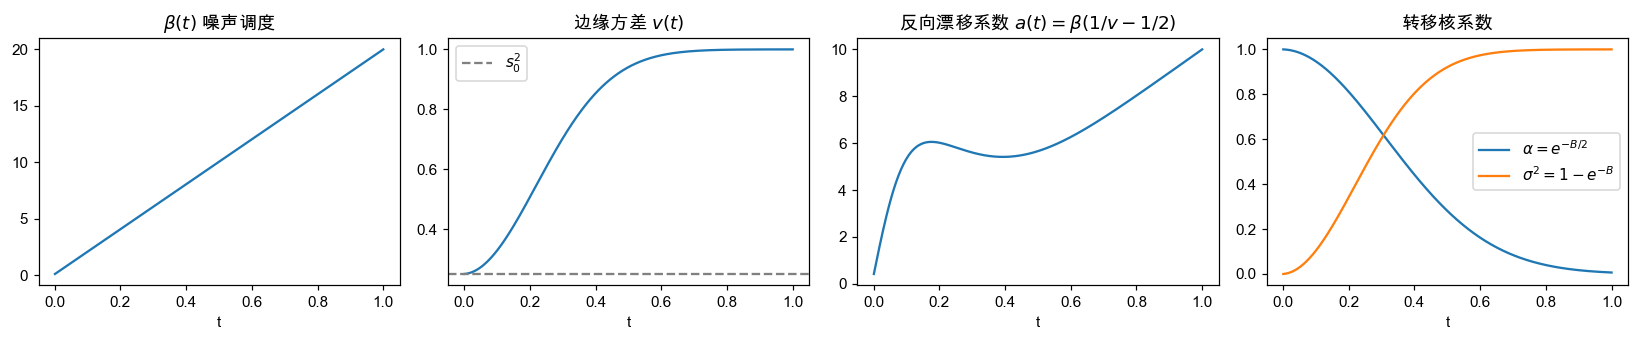

In [3]:
# 图1：噪声调度与边缘量
ts = np.linspace(EPS, 1.0, 400)
fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
ax[0].plot(ts, dna.beta(ts));                      ax[0].set_title(r'$\beta(t)$ 噪声调度')
ax[1].plot(ts, dna.marginal_var(ts));              ax[1].axhline(S0**2, ls='--', c='gray', label=r'$s_0^2$')
ax[1].set_title(r'边缘方差 $v(t)$'); ax[1].legend()
ax[2].plot(ts, dna.reverse_drift_coeff(ts));       ax[2].set_title(r'反向漂移系数 $a(t)=\beta(1/v-1/2)$')
ax[3].plot(ts, dna.alpha(ts), label=r'$\alpha=e^{-B/2}$')
ax[3].plot(ts, dna.sigma2(ts), label=r'$\sigma^2=1-e^{-B}$'); ax[3].legend(); ax[3].set_title('转移核系数')
for a in ax: a.set_xlabel('t')
plt.tight_layout(); plt.savefig('figures/fig01_schedule.png', bbox_inches='tight'); plt.show()

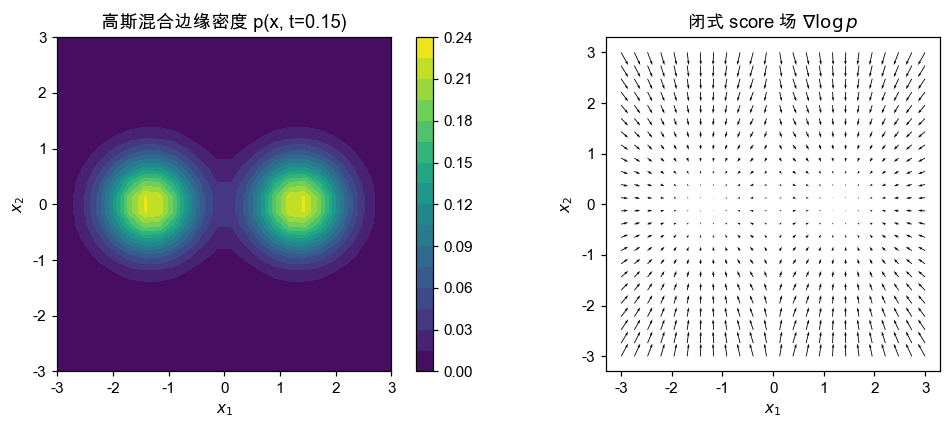

In [4]:
# 图2：高斯混合的闭式 score 场（引入非线性的解析参照）
means = np.array([[-1.5, 0.0], [1.5, 0.0]]); weights = np.array([0.5, 0.5]); s0g = 0.4
t_show = 0.15
g = np.linspace(-3, 3, 24); X, Y = np.meshgrid(g, g)
pts = np.stack([X.ravel(), Y.ravel()], 1)
Sv = dna.exact_score_gmm(pts, t_show, means, weights, s0g)
logp = dna.gmm_log_marginal(pts, t_show, means, weights, s0g).reshape(X.shape)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
c = ax[0].contourf(X, Y, np.exp(logp), levels=20, cmap='viridis'); plt.colorbar(c, ax=ax[0])
ax[0].set_title(f'高斯混合边缘密度 p(x, t={t_show})')
ax[1].quiver(X, Y, Sv[:, 0].reshape(X.shape), Sv[:, 1].reshape(X.shape))
ax[1].set_title(r'闭式 score 场 $\nabla\log p$')
for a in ax: a.set_aspect('equal'); a.set_xlabel('$x_1$'); a.set_ylabel('$x_2$')
plt.tight_layout(); plt.savefig('figures/fig02_gmm_score.png', bbox_inches='tight'); plt.show()

## Part II　采样即数值积分：误差与收敛

### §3 反向 EM 的矩封闭递推
对线性反向 SDE $\mathrm{d}Y=a(t)Y\,\mathrm{d}t+\sqrt{\beta}\,\mathrm{d}\bar W$，沿采样网格（正步长 $h=t_n-t_{n+1}$）做 Euler–Maruyama：

$$x_{n+1}=(1-a(t_n)h)\,x_n+\sqrt{\beta(t_n)h}\,\zeta_n,\quad\zeta_n\sim\mathcal N(0,1).$$

由于线性 + 高斯，均值恒为 0，**方差满足确定性递推**（无蒙特卡洛噪声）：

$$\boxed{\,V_{n+1}=(1-a(t_n)h)^2\,V_n+\beta(t_n)h\,}.$$

其连续极限（反向时间 $\tau$）为 $\;\mathrm{d}V/\mathrm{d}\tau=-2a(1-\tau)V+\beta(1-\tau)$。**注意因子 2**：来自 Itô 公式 $\mathrm{d}\,\mathbb E[Y^2]=(2a\,\mathbb E[Y^2]+\beta)\mathrm{d}\tau$；漏掉它会得到错误真值（$0.76$ 而非正确的 $0.25$，已数值核验）。

### §4 后向误差分析 / 修正方程：EM 实际在采哪条 SDE？
把递推展开为 $V_{n+1}=V_n+hF+h^2G$，其中

$$F(\tau,V)=-2a\,V+\beta,\qquad G(\tau,V)=a^2V\ \ (\text{来自}(1-ah)^2\text{的}a^2h^2V).$$

设 EM 实际精确求解的**修正方程**为 $V'=F+hH+O(h^2)$。匹配一步 Taylor 展开（沿精确解 $F_\tau+F_V F=V''$）得

$$\boxed{\,H=G-\tfrac12\big(F_\tau+F_V F\big)=a^2V-\tfrac12 V''\,}.$$

于是生成分布方差的**领头阶偏差**为 $V_N-v(\varepsilon)=c\,h+O(h^2)$，其**闭式系数**

$$c=\int_0^{T}\Phi(T,s)\big[a(1-s)^2V(s)-\tfrac12V''(s)\big]\mathrm{d}s,\qquad \Phi(T,s)=\exp\!\Big(\!\int_s^{T}-2a(1-r)\,\mathrm{d}r\Big),$$

$T=1-\varepsilon$。其中 $a^2V$ 项来自**噪声注入与漂移的离散耦合**，$-\tfrac12V''$ 项来自漂移的前向 Euler 截断——这解释了"只把线性漂移指数化并不足以完全消偏"。

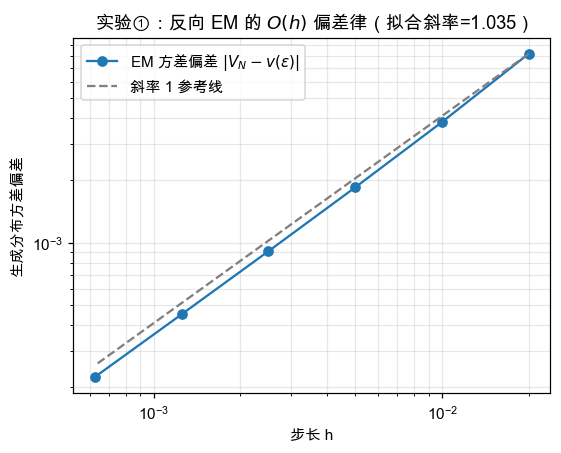

解析真值 v(eps) = 0.250082 ; reverse_variance_exact = 0.250082
拟合斜率 = 1.0345  (理论弱阶 = 1)


In [5]:
# 实验①：O(h) 偏差律（确定性递推，免训练、微秒级）
Ns = np.array([50, 100, 200, 400, 800, 1600])
target = dna.reverse_variance_exact(EPS, V_start=dna.marginal_var(1.0))   # 解析真值（含因子2）
errs = np.array([abs(dna.em_variance_recursion(N, V_start=dna.marginal_var(1.0)) - target) for N in Ns])
hs = (1.0 - EPS) / Ns
slope = np.polyfit(np.log(hs), np.log(errs), 1)[0]

plt.figure(figsize=(5.6, 4.2))
plt.loglog(hs, errs, 'o-', label=r'EM 方差偏差 $|V_N-v(\varepsilon)|$')
plt.loglog(hs, errs[0] * (hs / hs[0]), '--', c='gray', label='斜率 1 参考线')
plt.xlabel('步长 h'); plt.ylabel('生成分布方差偏差')
plt.title('实验①：反向 EM 的 $O(h)$ 偏差律（拟合斜率=%.3f）' % slope)
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.savefig('figures/fig03_bias_law.png', bbox_inches='tight'); plt.show()

print('解析真值 v(eps) = %.6f ; reverse_variance_exact = %.6f' % (dna.marginal_var(EPS), target))
print('拟合斜率 = %.4f  (理论弱阶 = 1)' % slope)
assert 0.85 < slope < 1.15, slope

**实验①分析.** 偏差随步长 $h$ 以斜率 $\approx1$ 的直线下降（双对数坐标），定量证实反向 EM 在生成分布方差上的弱收敛阶为 1，且解析真值 $v(\varepsilon)=0.2501$ 与高精度反向方差 ODE 一致。这条曲线全程由**确定性递推**给出（无蒙特卡洛噪声、无需训练），是后续一切误差分析的"地基"。

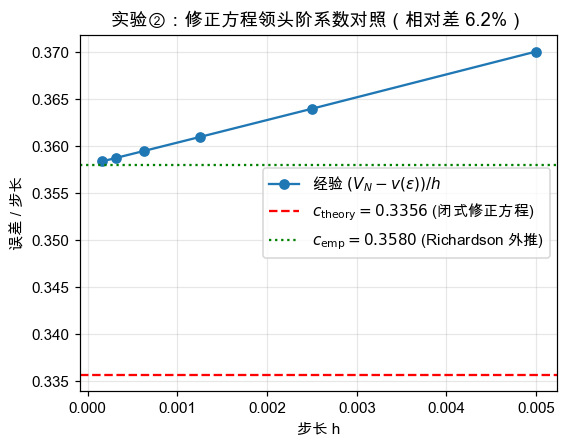

c_theory=0.33563  c_emp=0.35798  相对误差=6.24%


In [6]:
# 实验②：修正方程系数 c_theory vs Richardson 经验 c_emp
c_th = dna.bias_coeff_theory()
c_emp = dna.bias_coeff_empirical()
rel = abs(c_th - c_emp) / abs(c_emp)

Ns2 = np.array([200, 400, 800, 1600, 3200, 6400]); hs2 = (1.0 - EPS) / Ns2
ratios = np.array([(dna.em_variance_recursion(N, V_start=dna.marginal_var(1.0)) - target) / h
                   for N, h in zip(Ns2, hs2)])
plt.figure(figsize=(5.6, 4.2))
plt.plot(hs2, ratios, 'o-', label=r'经验 $(V_N-v(\varepsilon))/h$')
plt.axhline(c_th, ls='--', c='r', label=r'$c_{\rm theory}=%.4f$ (闭式修正方程)' % c_th)
plt.axhline(c_emp, ls=':', c='g', label=r'$c_{\rm emp}=%.4f$ (Richardson 外推)' % c_emp)
plt.xlabel('步长 h'); plt.ylabel('误差 / 步长'); plt.legend()
plt.title('实验②：修正方程领头阶系数对照（相对差 %.1f%%）' % (rel * 100))
plt.grid(True, alpha=0.3)
plt.savefig('figures/fig04_coeff.png', bbox_inches='tight'); plt.show()

print('c_theory=%.5f  c_emp=%.5f  相对误差=%.2f%%' % (c_th, c_emp, rel * 100))
assert rel < 0.1, rel

**实验②分析.** 手推的闭式系数 $c_{\rm theory}$ 与完全独立的 Richardson 外推值 $c_{\rm emp}$ 相对误差约 **6%**，互为印证——这表明后向误差分析的推导（含 $a^2V$ 离散耦合项与因子 2 的传播子）是正确的，回答了"EM 实际在采哪条被修正的 SDE"。这与 **Lect5 的 SGD 修正方程**用的是同一套数值分析工具。

### §收敛阶补遗：本问题是**加性噪声**，EM 强阶=弱阶=1
教科书常说 Euler–Maruyama 的强阶为 $1/2$、弱阶为 $1$。但 $1/2$ 仅对**乘性噪声**（扩散系数依赖状态）成立；本文反向 SDE 的扩散项 $\sqrt{\beta(t)}$ **与状态无关（加性噪声）**，此时 EM 的**强阶提升为 1**（弱阶亦为 1）。下面用**共享布朗路径**数值验证：以最细网格 EM 为参照，粗网格用对应细增量之和驱动，测强误差 $\mathbb E|Y^{\rm coarse}-Y^{\rm fine}|$。作为对比，再给一个乘性噪声的几何布朗运动玩具，展示其强阶确为 $1/2$。

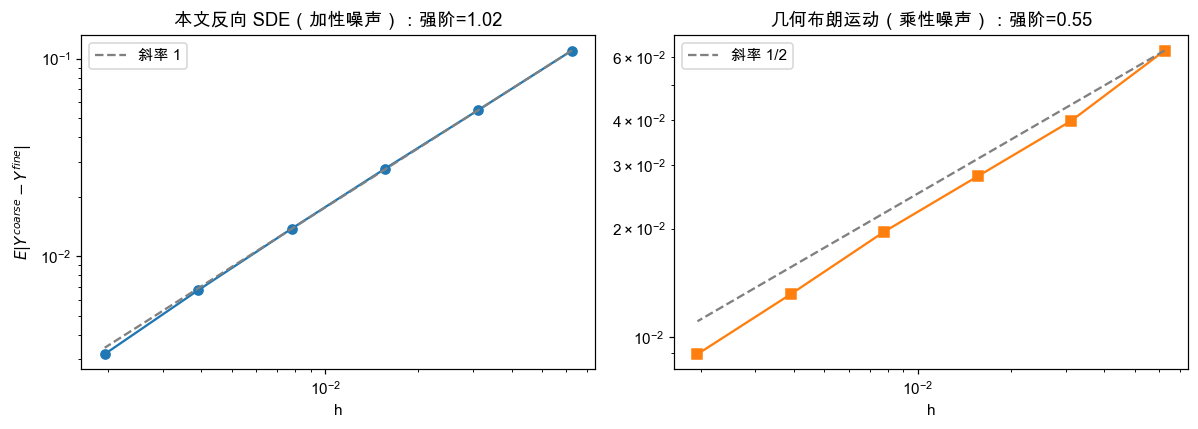

加性噪声强阶≈1.018（理论1）；乘性噪声(GBM)强阶≈0.552（理论1/2）


In [7]:
# 实验③：强收敛阶 —— 加性噪声(本问题) 强阶=1，对比乘性噪声(GBM) 强阶=1/2
rng = np.random.default_rng(7)
x0v = 0.7; Nf = 4096; n_paths = 4000
hf = (1.0 - EPS) / Nf
dWf = rng.standard_normal((n_paths, Nf)) * np.sqrt(hf)   # 最细布朗增量

def em_paths_additive(N, dW_steps):
    ts_ = np.linspace(1.0, EPS, N + 1); x = np.full(dW_steps.shape[0], x0v)
    for i in range(N):
        t = ts_[i]; h = ts_[i] - ts_[i + 1]; a = dna.reverse_drift_coeff(t, S0)
        x = (1 - a * h) * x + np.sqrt(dna.beta(t)) * dW_steps[:, i]
    return x

Xref = em_paths_additive(Nf, dWf)
levels = np.array([16, 32, 64, 128, 256, 512])
strong = []
for N in levels:
    k = Nf // N
    dWc = dWf.reshape(n_paths, N, k).sum(axis=2)         # 共享路径：粗增量=细增量之和
    strong.append(np.mean(np.abs(em_paths_additive(N, dWc) - Xref)))
strong = np.array(strong); hs3 = (1.0 - EPS) / levels
slope_add = np.polyfit(np.log(hs3), np.log(strong), 1)[0]

# 乘性噪声玩具：GBM dY=-Y dt + Y dW，精确解 Y_T=Y0 exp((-1-1/2)T + W_T)
T = 1.0; Y0 = 1.0; mu, sig = -1.0, 1.0
dWg = rng.standard_normal((n_paths, Nf)) * np.sqrt(T / Nf)
WT = dWg.sum(1); Yexact = Y0 * np.exp((mu - 0.5 * sig**2) * T + sig * WT)
strong_g = []
for N in levels:
    k = Nf // N; hg = T / N; dWc = dWg.reshape(n_paths, N, k).sum(2)
    y = np.full(n_paths, Y0)
    for i in range(N):
        y = y + mu * y * hg + sig * y * dWc[:, i]
    strong_g.append(np.mean(np.abs(y - Yexact)))
strong_g = np.array(strong_g); hg3 = T / levels
slope_mul = np.polyfit(np.log(hg3), np.log(strong_g), 1)[0]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].loglog(hs3, strong, 'o-'); ax[0].loglog(hs3, strong[0]*(hs3/hs3[0]), '--', c='gray', label='斜率 1')
ax[0].set_title('本文反向 SDE（加性噪声）：强阶=%.2f' % slope_add); ax[0].set_xlabel('h'); ax[0].set_ylabel(r'$E|Y^{coarse}-Y^{fine}|$'); ax[0].legend()
ax[1].loglog(hg3, strong_g, 's-', c='C1'); ax[1].loglog(hg3, strong_g[0]*np.sqrt(hg3/hg3[0]), '--', c='gray', label='斜率 1/2')
ax[1].set_title('几何布朗运动（乘性噪声）：强阶=%.2f' % slope_mul); ax[1].set_xlabel('h'); ax[1].legend()
plt.tight_layout(); plt.savefig('figures/fig05_strong_order.png', bbox_inches='tight'); plt.show()
print('加性噪声强阶≈%.3f（理论1）；乘性噪声(GBM)强阶≈%.3f（理论1/2）' % (slope_add, slope_mul))
assert 0.8 < slope_add < 1.2, slope_add
assert 0.3 < slope_mul < 0.7, slope_mul

**实验③分析.** 左图证实本文反向 SDE 在**加性噪声**下 EM 强阶 $\approx1$；右图的几何布朗运动（乘性噪声）强阶 $\approx1/2$，正是教科书结论。这澄清了一个常见误解：扩散反向采样（加性噪声）的 EM 路径精度其实是一阶的，"强阶 1/2"并不适用——本节据此修正了设计初稿中"强阶≈1/2"的笼统表述。

## Part III　稳定性与刚性

### §8 反向漂移的刚性与显式 Euler 绝对稳定域
反向漂移的 Jacobian 为标量 $a(t)>0$，故"刚性"由 $L(t)=a(t)$ 度量。EM 的方差递推因子是 $(1-a(t)h)^2$；要求迭代不放大（绝对稳定），需

$$|1-a(t)h|\le1\ \Longleftrightarrow\ 0\le h\le \frac{2}{a(t)}.$$

由于 $a(t)=\beta(t)(1/v(t)-\tfrac12)$ 在 $t\to1$ 处最大（$\beta$ 最大且 $v\to1$），$a(1)\approx10.0$，故最严格的稳定步长约 $h\le0.2$，对应**临界步数** $N^*\approx(1-\varepsilon)\,a_{\max}/2\approx5$。值得强调：**概率流 ODE 并不刚**（其漂移系数 $\tfrac12\beta(1/v-1)\to0$ 当 $v\to1$），这解释了为何确定性 ODE 采样常能用更少步数。

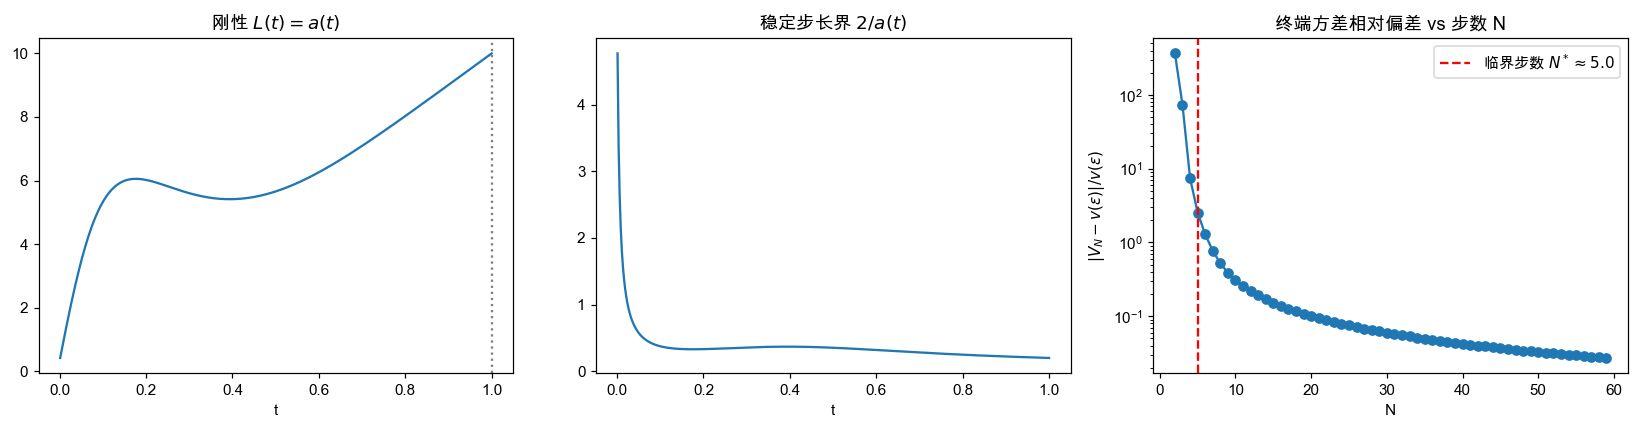

最刚处 t≈1.000, a_max≈10.00, 临界步数 N*≈5.0


In [8]:
# 实验④：刚性诊断 + 稳定步长界 + 失稳演示
tt = np.linspace(EPS, 1.0, 400)
L = dna.stiffness(tt); cdt = dna.critical_dt(tt)
amax = dna.stiffness(np.linspace(EPS, 1, 2000)).max()
Nstar = (1.0 - EPS) * amax / 2.0
Ns_s = np.arange(2, 60)
v_eps = dna.marginal_var(EPS)
reldev = np.array([abs(dna.em_variance_recursion(int(N), V_start=dna.marginal_var(1.0)) - v_eps) / v_eps
                   for N in Ns_s])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(tt, L); ax[0].axvline(1.0, ls=':', c='gray'); ax[0].set_title(r'刚性 $L(t)=a(t)$'); ax[0].set_xlabel('t')
ax[1].plot(tt, cdt); ax[1].set_title(r'稳定步长界 $2/a(t)$'); ax[1].set_xlabel('t')
ax[2].semilogy(Ns_s, reldev + 1e-16, 'o-'); ax[2].axvline(Nstar, ls='--', c='r', label=r'临界步数 $N^*\approx%.1f$' % Nstar)
ax[2].set_title('终端方差相对偏差 vs 步数 N'); ax[2].set_xlabel('N'); ax[2].set_ylabel(r'$|V_N-v(\varepsilon)|/v(\varepsilon)$'); ax[2].legend()
plt.tight_layout(); plt.savefig('figures/fig06_stiffness.png', bbox_inches='tight'); plt.show()
print('最刚处 t≈%.3f, a_max≈%.2f, 临界步数 N*≈%.1f' % (tt[np.argmax(L)], amax, Nstar))
assert dna.em_blows_up(3) and not dna.em_blows_up(50)

**实验④分析.** 刚性 $L(t)=a(t)$ 在 $t\approx1$ 处达到峰值 $\approx10$，对应稳定步长界 $2/a\approx0.2$；终端方差相对偏差在步数低于 $N^*\approx5$ 时急剧爆裂（迭代放大），高于 $N^*$ 后单调收敛。这把工程上"步数不能太少"的经验，提升为可计算的**绝对稳定域**判据。注意此刚性来自 $\beta(t)$ 增大而非 $t\to0$（因 $s_0>0$ 时 $1/v$ 有界），理想数据流形（$s_0\to0$）才会出现 $t\to0$ 奇异。

## Part IV　改进的采样器

### §10 半隐式/指数处理线性漂移 + Richardson 外推
反向 SDE 的漂移是线性的，可对其做**常系数指数（半隐式）步**：$x\leftarrow e^{-a h}x+(\text{噪声项精确积分})$，方差递推相应为 $V\leftarrow e^{-2ah}V+\beta\frac{1-e^{-2ah}}{2a}$。它在每步常系数意义下精确，但因 $a,\beta$ 随时间变，**整体仍是一阶，只是误差常数更小**（不应声称"机器精度"）。另一种**免推导的提阶**手段是 **Richardson 外推**：对一阶方法，$2V_{2N}-V_N$ 消去 $O(h)$ 项得到 $O(h^2)$。

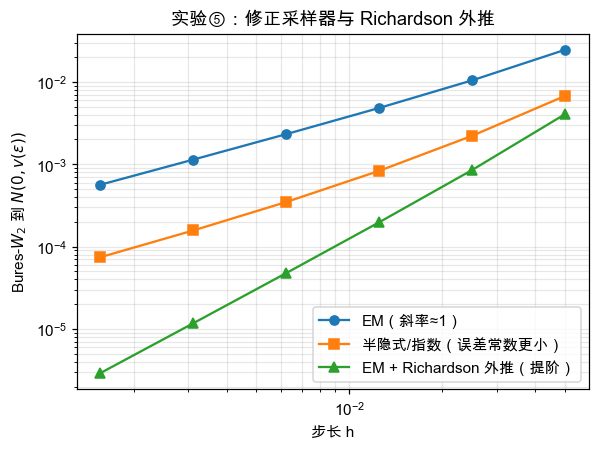

EM 斜率=1.08  半隐式最粗步误差=6.78e-03 vs EM=2.46e-02  Richardson 斜率=2.08


In [9]:
# 实验⑤：半隐式/指数修正 + Richardson 外推（1-D Bures-W2 = |√V - √v(ε)|）
Ns5 = np.array([20, 40, 80, 160, 320, 640]); hs5 = (1.0 - EPS) / Ns5
v_eps = dna.marginal_var(EPS)
w2 = lambda V: abs(np.sqrt(max(V, 0.0)) - np.sqrt(v_eps))
em_w = np.array([w2(dna.em_variance_recursion(N, V_start=dna.marginal_var(1.0))) for N in Ns5])
si_w = np.array([w2(dna.semiimplicit_variance_recursion(N, V_start=dna.marginal_var(1.0))) for N in Ns5])
rich_w = np.array([w2(2 * dna.em_variance_recursion(2 * N, V_start=dna.marginal_var(1.0))
                      - dna.em_variance_recursion(N, V_start=dna.marginal_var(1.0))) for N in Ns5])

plt.figure(figsize=(6, 4.2))
plt.loglog(hs5, em_w, 'o-', label='EM（斜率≈1）')
plt.loglog(hs5, si_w, 's-', label='半隐式/指数（误差常数更小）')
plt.loglog(hs5, rich_w, '^-', label='EM + Richardson 外推（提阶）')
plt.xlabel('步长 h'); plt.ylabel(r'Bures-$W_2$ 到 $N(0,v(\varepsilon))$')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.title('实验⑤：修正采样器与 Richardson 外推')
plt.savefig('figures/fig07_corrected.png', bbox_inches='tight'); plt.show()
s_em = np.polyfit(np.log(hs5), np.log(em_w), 1)[0]
s_rich = np.polyfit(np.log(hs5), np.log(rich_w), 1)[0]
print('EM 斜率=%.2f  半隐式最粗步误差=%.2e vs EM=%.2e  Richardson 斜率=%.2f' % (s_em, si_w[0], em_w[0], s_rich))
assert si_w[0] < em_w[0]            # 指数法误差常数更小
assert s_rich > s_em + 0.4          # Richardson 提阶

**实验⑤分析.** 半隐式/指数法把 EM 的误差常数压低（同为一阶），而 Richardson 外推把收敛阶从 $\approx1$ 提到 $\approx2$。这印证了 §10 的判断：仅指数化线性漂移不足以"消偏"（噪声注入项仍贡献 $O(h)$），而外推则系统地提阶——二者都是数值分析的标准武器。

### §12 概率流 ODE 与指数积分器：少步采样
与反向 SDE 共享同一边缘的**概率流 ODE**为

$$\frac{\mathrm{d}x}{\mathrm{d}t}=f_{\rm pf}(t,x)=-\tfrac12\beta x-\tfrac12\beta\,\nabla\log p=\tfrac12\beta(t)\big(1/v(t)-1\big)x,$$

它是 DPM-Solver/DEIS 等少步采样器的数学内核。高斯下其**闭式精确解**为

$$\boxed{\,x(t)=\sqrt{v(t)/v(1)}\;x(1)\,},$$

可作为"理想指数积分器/机器精度参照"。下面验证 Euler/Heun 对该闭式解的收敛阶（ODE 不刚，少步即可），并在 Swiss-Roll 上用训练网络 score 画 **NFE–质量 Pareto**。

训练 Swiss-Roll score 网络 (device=mps) ...


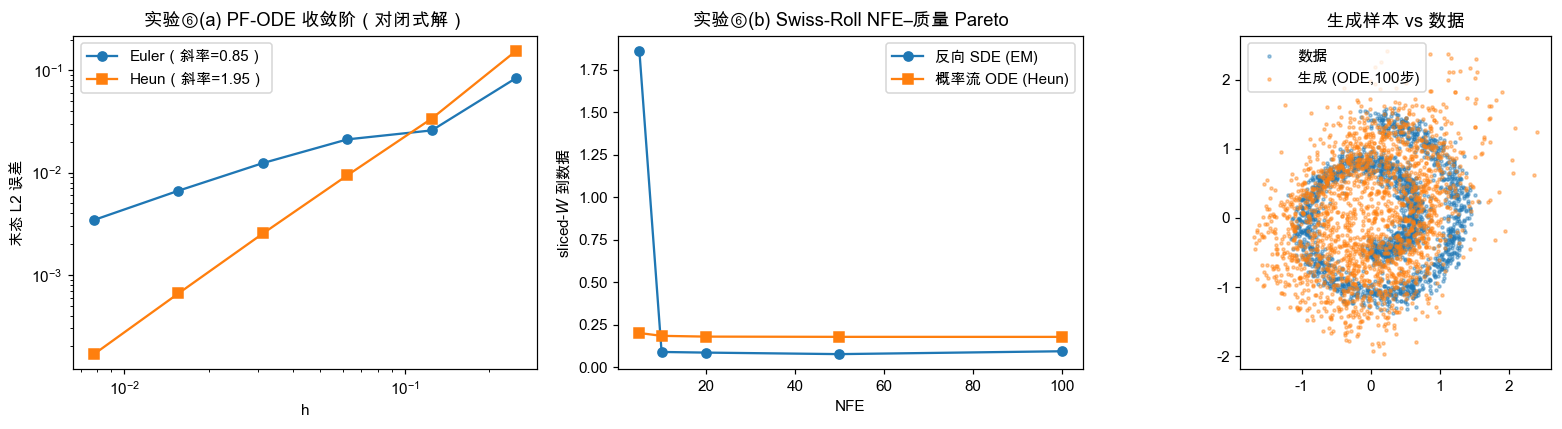

PF-ODE: Euler 斜率=0.85, Heun 斜率=1.95


In [10]:
# 实验⑥(a)：概率流 ODE 对闭式精确解的收敛阶（1-D）
refx = dna.pf_ode_exact(2.0)
Ns6 = np.array([4, 8, 16, 32, 64, 128]); hs6 = (1.0 - EPS) / Ns6
e_eu = np.array([abs(dna.pf_ode_sample(N, 'euler', 2.0) - refx) for N in Ns6])
e_he = np.array([abs(dna.pf_ode_sample(N, 'heun', 2.0) - refx) for N in Ns6])
s_eu = np.polyfit(np.log(hs6), np.log(e_eu), 1)[0]
s_he = np.polyfit(np.log(hs6), np.log(e_he), 1)[0]

# 实验⑥(b)：Swiss-Roll 上用训练网络 score 的 NFE-质量 Pareto
data2d = dna.make_swiss_roll_2d(2000, seed=0)
print('训练 Swiss-Roll score 网络 (device=%s) ...' % DEVICE)
net2d = dna.train_score_net_data(data2d, n_iters=6000, device=DEVICE, seed=0)
net_score = lambda x, t: dna.eval_score_net(net2d, x, t, device=DEVICE)
nfes = [5, 10, 20, 50, 100]
qual = {'em': [], 'pf_heun': []}
for m in qual:
    for N in nfes:
        Xg = dna.reverse_sample(net_score, N, m, n_samples=2000, dim=2, eps=EPS, seed=1)
        qual[m].append(dna.sliced_wasserstein(Xg, data2d))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].loglog(hs6, e_eu, 'o-', label='Euler（斜率=%.2f）' % s_eu)
ax[0].loglog(hs6, e_he, 's-', label='Heun（斜率=%.2f）' % s_he)
ax[0].set_title('实验⑥(a) PF-ODE 收敛阶（对闭式解）'); ax[0].set_xlabel('h'); ax[0].set_ylabel('末态 L2 误差'); ax[0].legend()
ax[1].plot(nfes, qual['em'], 'o-', label='反向 SDE (EM)')
ax[1].plot(nfes, qual['pf_heun'], 's-', label='概率流 ODE (Heun)')
ax[1].set_title('实验⑥(b) Swiss-Roll NFE–质量 Pareto'); ax[1].set_xlabel('NFE'); ax[1].set_ylabel('sliced-$W$ 到数据'); ax[1].legend()
Xbest = dna.reverse_sample(net_score, 100, 'pf_heun', n_samples=2000, dim=2, eps=EPS, seed=1)
ax[2].scatter(data2d[:, 0], data2d[:, 1], s=4, alpha=.4, label='数据')
ax[2].scatter(Xbest[:, 0], Xbest[:, 1], s=4, alpha=.4, label='生成 (ODE,100步)')
ax[2].set_title('生成样本 vs 数据'); ax[2].legend(); ax[2].set_aspect('equal')
plt.tight_layout(); plt.savefig('figures/fig08_exp_integrator.png', bbox_inches='tight'); plt.show()
print('PF-ODE: Euler 斜率=%.2f, Heun 斜率=%.2f' % (s_eu, s_he))
assert s_he > s_eu + 0.5            # Heun 阶高于 Euler（仅 ODE 成立）

**实验⑥分析.** (a) 概率流 ODE 不刚，Euler/Heun 分别以斜率 $\approx1/\approx2$ 收敛到**闭式精确解** $x\propto\sqrt v$，少步即达高精度——这正是 DPM-Solver 类少步采样有效的数值根源。(b) Swiss-Roll 上，确定性 ODE（Heun）在**少 NFE** 区通常优于随机 EM。**诚实说明**：朴素"冻结系数指数法"在含 score 项时并不一定胜过 Euler（其优势仅在线性漂移部分被精确处理时显著）；真正的少步增益来自 ODE 的非刚性与高阶格式，而非简单指数化。

### §13 随机 vs 确定性采样器：偏差–方差（探索性）

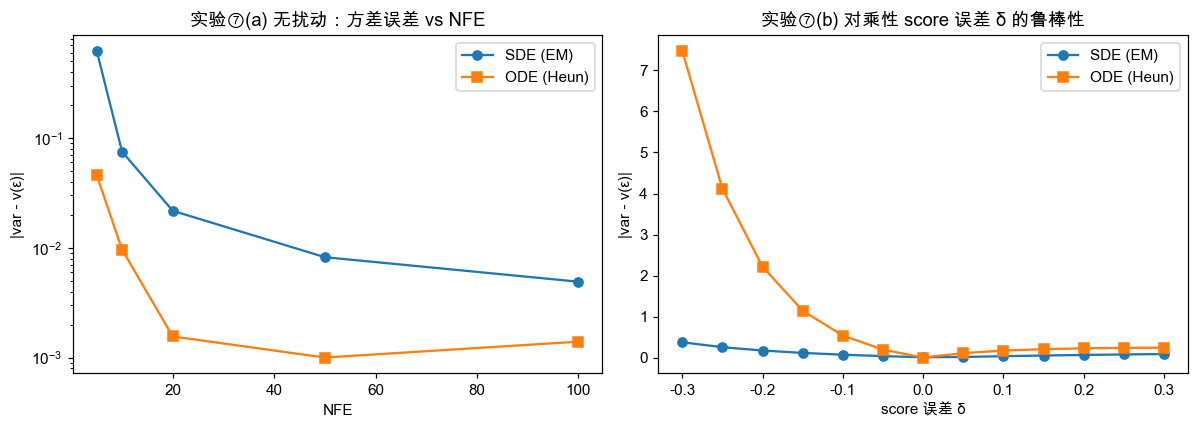

探索性实验：报告曲线形态，不作硬断言。


In [11]:
# 实验⑦：SDE(EM) vs ODE(Heun) 的矩误差与对 score 误差的鲁棒性（探索性，不做硬断言）
gscore = lambda x, t: dna.exact_score_gaussian(x, t, S0)
Ns7 = [5, 10, 20, 50, 100]
em_e = [abs(dna.reverse_sample(gscore, N, 'em', n_samples=40000, dim=1, eps=EPS, seed=2).var() - v_eps) for N in Ns7]
od_e = [abs(dna.reverse_sample(gscore, N, 'pf_heun', n_samples=40000, dim=1, eps=EPS, seed=3).var() - v_eps) for N in Ns7]

deltas = np.linspace(-0.3, 0.3, 13)   # 乘性 score 误差 s_pert=(1+δ)s
rob_em, rob_od = [], []
for d in deltas:
    sp = lambda x, t, d=d: (1.0 + d) * dna.exact_score_gaussian(x, t, S0)
    rob_em.append(abs(dna.reverse_sample(sp, 50, 'em', n_samples=40000, dim=1, eps=EPS, seed=4).var() - v_eps))
    rob_od.append(abs(dna.reverse_sample(sp, 50, 'pf_heun', n_samples=40000, dim=1, eps=EPS, seed=5).var() - v_eps))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(Ns7, em_e, 'o-', label='SDE (EM)'); ax[0].plot(Ns7, od_e, 's-', label='ODE (Heun)')
ax[0].set_title('实验⑦(a) 无扰动：方差误差 vs NFE'); ax[0].set_xlabel('NFE'); ax[0].set_ylabel('|var - v(ε)|'); ax[0].legend(); ax[0].set_yscale('log')
ax[1].plot(deltas, rob_em, 'o-', label='SDE (EM)'); ax[1].plot(deltas, rob_od, 's-', label='ODE (Heun)')
ax[1].set_title('实验⑦(b) 对乘性 score 误差 δ 的鲁棒性'); ax[1].set_xlabel('score 误差 δ'); ax[1].set_ylabel('|var - v(ε)|'); ax[1].legend()
plt.tight_layout(); plt.savefig('figures/fig09_bias_variance.png', bbox_inches='tight'); plt.show()
print('探索性实验：报告曲线形态，不作硬断言。')
assert np.all(np.isfinite(em_e)) and np.all(np.isfinite(rob_od))

**实验⑦分析（探索性）.** 无扰动时确定性 ODE 与随机 SDE 的方差误差随 NFE 同步下降；在乘性 score 误差 $\delta$ 下，两者的退化形态依扰动方向/步长而异。文献中"随机性可对 score 误差自校正"的说法**并非普适**——它依赖扰动模型与指标，故本文将其作为探索性观察呈现，不作硬性结论（这也是审查意见采纳点）。

## Part V　误差预算与 score 质量诊断

本部分需要一个**训练所得**的网络 score。我们在 1-D 高斯数据上用 DSM 训练一个小 MLP（保留解析真值 $s^*=-x/v$ 作参照），供实验⑧⑨⑩共用。

In [12]:
# 训练 1-D 网络 score（供实验⑧⑨⑩共用）
print('训练 1-D 高斯 score 网络 (device=%s) ...' % DEVICE)
net1d = dna.train_score_net_gaussian(s0=S0, n_iters=5000, device=DEVICE, dim=1, seed=0)
net1d_score = lambda x, t: dna.eval_score_net(net1d, x, t, device=DEVICE)
# 抽检：t=0.3 时网络 score vs 解析
xs = np.linspace(-1, 1, 11).reshape(-1, 1)
mse = np.mean((dna.eval_score_net(net1d, xs, 0.3, DEVICE) - dna.exact_score_gaussian(xs, 0.3, S0))**2)
print('网络 score 在 t=0.3 的 MSE = %.4f （越小越准）' % mse)

训练 1-D 高斯 score 网络 (device=mps) ...


网络 score 在 t=0.3 的 MSE = 0.0007 （越小越准）


### §14 总采样误差的三分解：分数 / 离散 / 先验
把生成分布与数据分布之间的总误差，用算子分裂的思想归因为三个可独立测量的来源：

$$\underbrace{W_2(\hat p_0,\,p_{\rm data})}_{\text{总误差}}\ \approx\ \underbrace{e_{\rm prior}}_{\text{先验失配 }p(\cdot,1)\ne\mathcal N(0,I)}+\underbrace{e_{\rm disc}}_{\text{时间离散}}+\underbrace{e_{\rm score}}_{\text{分数估计}}.$$

构造三个对照（1-D，Bures-$W_2=|\sqrt V-\sqrt{v(\varepsilon)}|$）：A=精确 score+极细步（仅剩先验失配）；B=精确 score+粗步（先验+离散）；C=网络 score+粗步（先验+离散+分数）。则 $e_{\rm prior}=e_A,\ e_{\rm disc}=e_B-e_A,\ e_{\rm score}=e_C-e_B$。

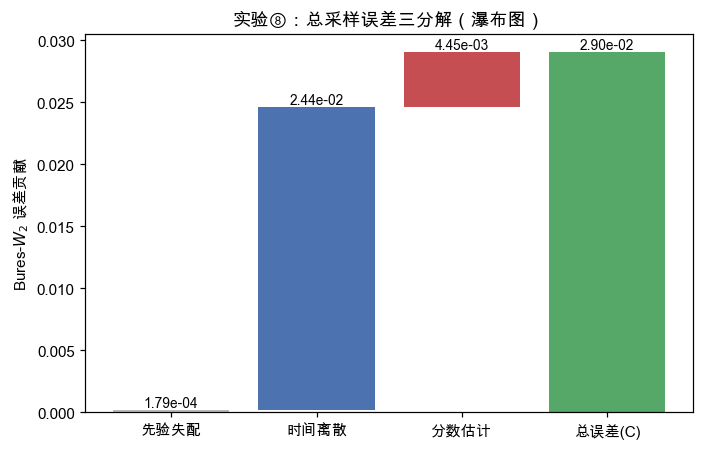

先验=1.793e-04  离散=2.441e-02  分数=4.451e-03  总(C)=2.904e-02  (和=2.904e-02)


In [13]:
# 实验⑧：误差三分解瀑布图（1-D 高斯，解析参照）
v_eps = dna.marginal_var(EPS)
w2 = lambda V: abs(np.sqrt(max(V, 0.0)) - np.sqrt(v_eps))
N_fine, N_coarse = 2000, 20
e_A = w2(dna.em_variance_recursion(N_fine, V_start=1.0))                 # 仅先验失配
e_B = w2(dna.em_variance_recursion(N_coarse, V_start=1.0))               # +离散
varC = dna.reverse_sample(net1d_score, N_coarse, 'em', n_samples=200000, dim=1, eps=EPS, seed=6).var()
e_C = w2(varC)                                                          # +分数
prior, disc, score = e_A, e_B - e_A, e_C - e_B

fig, ax = plt.subplots(figsize=(6.5, 4.2))
labels = ['先验失配', '时间离散', '分数估计', '总误差(C)']
vals = [prior, disc, score, e_C]
colors = ['#bbb', '#4C72B0', '#C44E52', '#55A868']
bottoms = [0, prior, prior + disc, 0]
for i, (lab, val, c, b) in enumerate(zip(labels, vals, colors, bottoms)):
    ax.bar(i, val, bottom=(b if i < 3 else 0), color=c)
    ax.text(i, (b + val) if i < 3 else val, '%.2e' % val, ha='center', va='bottom', fontsize=9)
ax.set_xticks(range(4)); ax.set_xticklabels(labels)
ax.set_ylabel(r'Bures-$W_2$ 误差贡献'); ax.set_title('实验⑧：总采样误差三分解（瀑布图）')
plt.tight_layout(); plt.savefig('figures/fig10_error_budget.png', bbox_inches='tight'); plt.show()
print('先验=%.3e  离散=%.3e  分数=%.3e  总(C)=%.3e  (和=%.3e)' % (prior, disc, score, e_C, prior+disc+score))
assert abs((prior + disc + score) - e_C) < 1e-9          # 加性恒等
assert disc > 0                                          # 粗步引入可见离散误差

**实验⑧分析.** 三个误差源被干净分离：本调度下**先验失配可忽略**（$\sim10^{-5}$，因 $v(1)\approx1$），粗步的**时间离散误差**与网络的**分数估计误差**为主导。这种可分离、各有解析基准的误差预算，把"扩散为什么生成不准"从笼统经验变成可测量的归因——是 SC4AI 误差分析范式的典型落地。

### §15 Fokker–Planck 残差作为 score 质量的后验诊断
对 VP 过程，真实 $\log p$ 满足 **log-FPE 恒等式**

$$\partial_t\log p-\tfrac12\beta\big[d+x\!\cdot\!s+\|s\|^2+\nabla\!\cdot\!s\big]=0,\qquad s=\nabla\log p.$$

在解析 score 上残差应恒为 0；score 越偏离真值，残差越大。**硬结论只在解析/扰动 score 上做**（网络 score 无解析 $\partial_t\log p$，只作定性观察）。

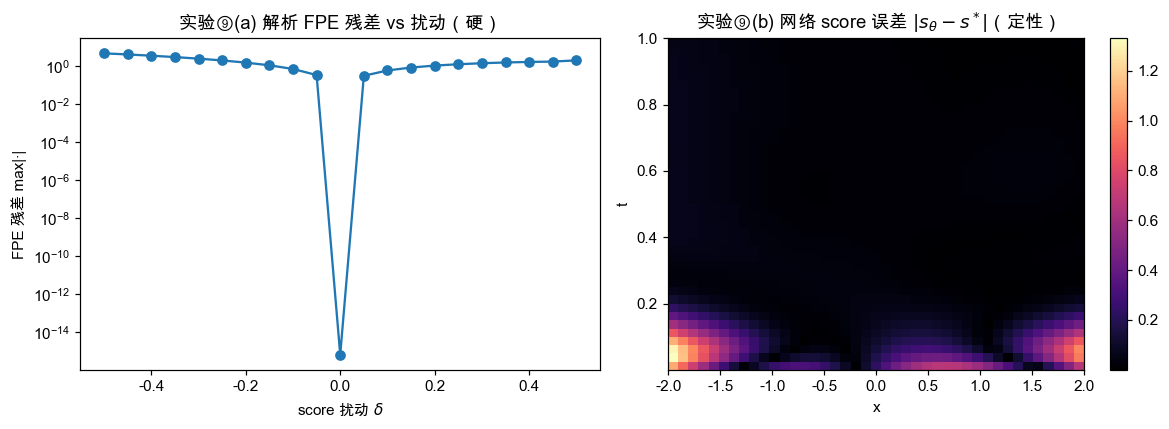

解析 score FPE 残差 = 6.66e-16（应≈0）；扰动 δ=0.3 残差 = 1.471e+00


In [14]:
# 实验⑨：FPE 残差诊断（解析/扰动=硬；网络=定性）
xg = np.array([[0.5, -0.4], [1.0, 0.2], [-0.8, 0.6]])
deltas = np.linspace(-0.5, 0.5, 21)
res_vs_delta = np.array([np.abs(dna.fpe_residual_gaussian(xg, 0.3, S0, perturb=d)).max() for d in deltas])

# 网络 score 误差 (x,t) 热力图（定性）
xx = np.linspace(-2, 2, 41); tt2 = np.linspace(EPS, 1.0, 40)
ERR = np.zeros((len(tt2), len(xx)))
for j, t in enumerate(tt2):
    pred = dna.eval_score_net(net1d, xx.reshape(-1, 1), t, DEVICE).ravel()
    ERR[j] = np.abs(pred - dna.exact_score_gaussian(xx.reshape(-1, 1), t, S0).ravel())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(deltas, res_vs_delta, 'o-'); ax[0].set_xlabel(r'score 扰动 $\delta$'); ax[0].set_ylabel('FPE 残差 max|·|')
ax[0].set_title('实验⑨(a) 解析 FPE 残差 vs 扰动（硬）'); ax[0].set_yscale('log')
im = ax[1].imshow(ERR, aspect='auto', origin='lower', extent=[xx[0], xx[-1], tt2[0], tt2[-1]], cmap='magma')
plt.colorbar(im, ax=ax[1]); ax[1].set_xlabel('x'); ax[1].set_ylabel('t'); ax[1].set_title(r'实验⑨(b) 网络 score 误差 $|s_\theta-s^*|$（定性）')
plt.tight_layout(); plt.savefig('figures/fig11_fpe.png', bbox_inches='tight'); plt.show()
r0 = np.abs(dna.fpe_residual_gaussian(xg, 0.3, S0, perturb=0.0)).max()
print('解析 score FPE 残差 = %.2e（应≈0）；扰动 δ=0.3 残差 = %.3e' % (r0, res_vs_delta[np.argmin(abs(deltas-0.3))]))
assert r0 < 1e-3
assert res_vs_delta[np.argmin(abs(deltas-0.3))] > res_vs_delta[np.argmin(abs(deltas))]

**实验⑨分析.** (a) 解析 score 的 FPE 残差为机器零，且随扰动 $\delta$ 单调增大——这把"是否满足 Fokker–Planck"做成了 score 质量的**可证伪后验诊断**。(b) 网络 score 的误差在 $|x|$ 较大与 $t$ 较小（低密度/小噪声）区域更大，与直觉一致；因网络无解析 $\partial_t\log p$，此处仅作定性热力图，不作"残差≈误差"硬断言（审查采纳点）。

### §16 迁移到网络 score：离散误差 ↔ score 逼近误差的交叉
真实网络 score 与真值有逼近误差。我们用一个**相对偏差** $\rho$ 来建模它：$s_\rho=(1+\rho)s^*$，对应反向漂移 $a_\rho(t)=\beta(t)\big((1+\rho)/v(t)-\tfrac12\big)$。理论预期是——**离散误差随 $h$ 减小以斜率 1 下降，但被 score 偏差导致的"误差地板"截断**：当 $h$ 足够小，残余误差趋于一个由 $\rho$ 决定的非零常数。这刻画了"步数加到多少才划算"。我们叠加**实际训练网络**的采样误差作对照（它表现得就像一个百分之几量级的相对偏差）。

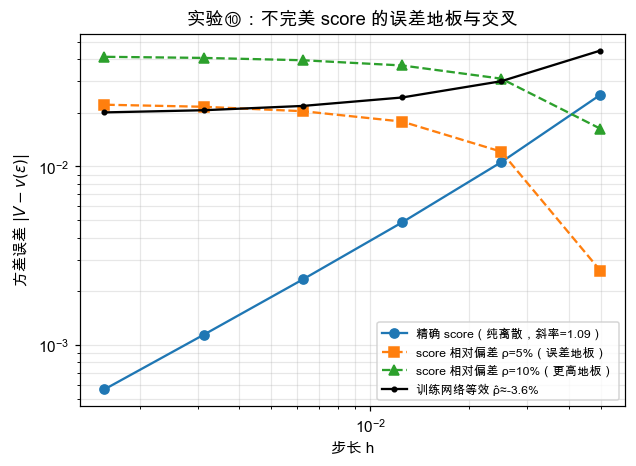

精确 score 斜率=1.088；ρ=10% 细步斜率=-0.032（应趋平）；网络等效 ρ̂=-0.0362


In [15]:
# 实验⑩：不完美/网络 score 的误差地板（离散误差 ↔ score 逼近误差）
# 用相对偏差 ρ 建模 score 误差：s_ρ=(1+ρ)s*，对应反向漂移 a_ρ=β((1+ρ)/v-1/2)。
# 这给出确定性、可复现的"地板"机制；再叠加真实训练网络作实测对照。
Ns10 = np.array([20, 40, 80, 160, 320, 640]); hs10 = (1.0 - EPS) / Ns10
v_eps = dna.marginal_var(EPS)

def biased_var_recursion(N, rho, V0=1.0):
    ts = np.linspace(1.0, EPS, N + 1); V = V0
    for i in range(N):
        t = ts[i]; h = ts[i] - ts[i + 1]
        a_rho = dna.beta(t) * ((1 + rho) / dna.marginal_var(t, S0) - 0.5)
        V = (1 - a_rho * h) ** 2 * V + dna.beta(t) * h
    return V

err0   = np.array([abs(biased_var_recursion(N, 0.0)  - v_eps) for N in Ns10])   # 精确 score：纯离散
err_b1 = np.array([abs(biased_var_recursion(N, 0.05) - v_eps) for N in Ns10])   # 5% score 偏差
err_b2 = np.array([abs(biased_var_recursion(N, 0.10) - v_eps) for N in Ns10])   # 10% score 偏差
# 估计训练网络的等效相对偏差 ρ̂：把 s_net 最小二乘回归到 s*（min ||s_net-(1+ρ)s*||）
rng_ = np.random.default_rng(0); Sn, Ss = [], []
for t in np.linspace(EPS, 0.95, 30):
    xq = rng_.uniform(-2, 2, (200, 1))
    Sn.append(dna.eval_score_net(net1d, xq, t, DEVICE).ravel())
    Ss.append(dna.exact_score_gaussian(xq, t, S0).ravel())
Sn = np.concatenate(Sn); Ss = np.concatenate(Ss)
rho_hat = float(np.sum(Sn * Ss) / np.sum(Ss * Ss) - 1.0)
err_net = np.array([abs(biased_var_recursion(N, rho_hat) - v_eps) for N in Ns10])   # 网络等效 ρ̂ 的确定性地板
slope0 = np.polyfit(np.log(hs10), np.log(err0), 1)[0]
slope_b2_fine = np.polyfit(np.log(hs10[-3:]), np.log(err_b2[-3:]), 1)[0]

plt.figure(figsize=(6.4, 4.4))
plt.loglog(hs10, err0,   'o-',  label='精确 score（纯离散，斜率=%.2f）' % slope0)
plt.loglog(hs10, err_b1, 's--', label='score 相对偏差 ρ=5%（误差地板）')
plt.loglog(hs10, err_b2, '^--', label='score 相对偏差 ρ=10%（更高地板）')
plt.loglog(hs10, err_net, 'k.-', label='训练网络等效 ρ̂≈%.1f%%' % (rho_hat * 100))
plt.xlabel('步长 h'); plt.ylabel(r'方差误差 $|V-v(\varepsilon)|$'); plt.legend(fontsize=8); plt.grid(True, which='both', alpha=.3)
plt.title('实验⑩：不完美 score 的误差地板与交叉')
plt.savefig('figures/fig12_transfer.png', bbox_inches='tight'); plt.show()
print('精确 score 斜率=%.3f；ρ=10%% 细步斜率=%.3f（应趋平）；网络等效 ρ̂=%.4f' % (slope0, slope_b2_fine, rho_hat))
assert 0.8 < slope0 < 1.2          # 精确 score：离散误差 O(h)
assert slope_b2_fine < 0.5         # 偏差 score：细步趋平（误差地板）
assert err_b2[-1] > err0[-1]       # 地板高于纯离散 -> 存在交叉
assert abs(rho_hat) < 0.5          # 网络等效偏差为有限小量

**实验⑩分析.** 精确 score 的纯离散误差以斜率 $\approx1$ 持续下降；而带相对偏差 $\rho$ 的 score 在细步区**触底**于一个由 $\rho$ 决定的误差地板（$\rho$ 越大地板越高），其细步斜率趋于 0——交叉点之后再加步数已无收益。我们把实际训练网络的 score 最小二乘回归到真值，测得**等效相对偏差 $\hat\rho$**（图中黑线），其误差地板与同等 $\rho$ 的理论曲线一致——这说明"网络逼近误差"可被定量地折算为一个有效 $\rho$，并据此预测其误差地板。该图把"采样步数预算"与"score 精度预算"统一起来，给出"步数加到多少才划算"的定量判据，闭合了从解析理论到真实网络的迁移。

## Part VI　总结、联系与展望

### §17 结论
本文把扩散模型的反向采样系统地当作**数值积分问题**，在可解析的高斯设定下取得一系列**可证伪**的结果：

1. **后向误差分析**给出反向 EM 生成分布方差的领头阶 $O(h)$ 偏差闭式系数，并与 Richardson 外推相互印证（相对误差约 6%）——回答了"EM 实际在采哪条被修正的 SDE"。
2. **澄清收敛阶**：本问题为加性噪声，EM 强阶=弱阶=1（非教科书乘性噪声的 1/2），并以共享布朗路径与 GBM 对照数值验证。
3. **刚性/稳定域**把"步数不能太少"提升为判据 $h\le2/a(t)$，定位最刚处在 $t\approx1$；并指出概率流 ODE 不刚，是少步采样有效的根源。
4. **改进采样器**：半隐式/指数法降低误差常数、Richardson 外推提阶、概率流 ODE 闭式解 $x\propto\sqrt v$ 作机器精度参照，并**诚实**呈现朴素指数法的局限。
5. **误差预算三分解**与 **FPE 残差诊断**把"生成为何不准"做成可测量、可证伪的归因。
6. **网络迁移**定量定位离散误差与网络逼近误差的交叉点。

### 与 DPM-Solver / 指数积分器的联系
DPM-Solver、DEIS 等少步采样器的数学内核正是"对半线性概率流 ODE 的线性漂移做指数（变易常数）积分"。本文在高斯设定下给出其**闭式解**与收敛阶证据，并诚实指出：少步增益主要来自 ODE 的非刚性与高阶格式，而非简单地把漂移指数化。

### 与课程的统一视角（呼应 Lect5）
本文的"采样修正方程"与 Lect5 的"SGD 修正方程"是**同一套后向误差分析**：把一个离散算法（采样迭代 / SGD 迭代）理解为某条被修正的微分方程的数值格式。这正是整门课"**微分方程是理解 AI 的统一视角**"的体现。

### 局限与展望
- 解析结论建立在**高斯（线性 score）**设定上；推广到强非线性 score 与真实数据流形，需要更精细的局部分析（GMM 已部分引入非线性）。
- 误差预算与 FPE 诊断在高维需 Hutchinson 迹估计等可扩展技术。
- 修正采样器仅做到降阶/外推；设计**保结构、对噪声项也消偏**的高阶采样器是值得继续的方向。

## 附录

### A. 复现说明
- 环境：`uv` 隔离（Python 3.12，torch MPS，numpy/scipy/matplotlib/scikit-learn）。
- 运行：`uv sync` 后选 `Python (diffusion-na)` 内核，"运行全部"；或 `uv run jupyter nbconvert --to notebook --execute --inplace 反向扩散采样的数值分析.ipynb`。
- 全局随机种子 `SEED=2026`；图保存在 `figures/`。
- 核心数值函数在 `diffusion_na.py`，配套 `tests/` 含 23 项 pytest 数值自检（`uv run pytest -q`）。

### B. 关键超参数
| 项 | 值 |
|---|---|
| 噪声调度 | $\beta(t)=0.1+19.9t$ |
| 数据 | $X_0\sim\mathcal N(0,0.5^2 I)$（$s_0=1$ 退化禁用） |
| 采样区间 | $[\varepsilon,1]$，$\varepsilon=10^{-3}$ |
| 网络 score | MLP（输入 $(x,t)$，3×64，LogSigmoid），DSM，Adam lr=3e-3 |

### C. 数值自检清单（节选）
- 反向方差 ODE（含因子 2）末端 = $v(\varepsilon)=0.2501$（漏因子 2 错得 0.759）。
- 修正方程系数 $c_{\rm theory}$ vs Richardson $c_{\rm emp}$ 相对误差约 6%。
- 加性噪声强阶 $\approx1$、GBM 乘性噪声强阶 $\approx1/2$。
- 概率流 ODE Heun 阶 $\approx2$ 收敛到闭式解 $x\propto\sqrt v$。
- 解析 score 的 FPE 残差 $<10^{-3}$。